In [47]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))  # go up to project root
from pydantic import BaseModel
from typing import Literal
from user_profile.schema import SearchParams, State, UserProfile, VideoInfo, TranscriptAnalysis, ScoreAnalysis
from prompts import orchestrator_prompt, score_prompt, search_prompt, transcript_prompt, profile_prompt
import os
from langchain_deepseek import ChatDeepSeek
from IPython.display import Image, display
from tools import rapidapi_youtube, youtube_transcript
import unicodedata
import importlib
from tqdm import tqdm
from trustcall import create_extractor
import uuid

In [48]:
from langgraph.graph import StateGraph, MessagesState, END, START
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, merge_message_runs
from langgraph.checkpoint.memory import MemorySaver

In [3]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "language-learning-agent"

In [4]:
class ExecuteIntent(BaseModel):
    """Call this to execute the user's intent"""
    intent: Literal[
        "full_search",
        "transcript_only", 
        "rerank_only",
        "profile_update",
        "out_of_scope"
    ]
    search_params: SearchParams | None = None
    video_id: str | None = None

In [5]:
model = ChatDeepSeek(
    model = "deepseek-chat",
    temperature=0.5
)

In [6]:
def get_user_profile(user_id: str, store : BaseStore) -> UserProfile:
    # In a real application, this would fetch the user profile from a database
    # For this example, we'll just return a dummy profile
    namespace = ("profile", user_id)
    memories = store.search(namespace)
    if memories:
        user_profile = memories[0].value
    else:
        user_profile = None
    return user_profile

In [82]:
def orchestrator(state : State, config : RunnableConfig, store : BaseStore):
    
    for msg in state["messages"]:
        print(f"{msg.type}: {str(msg.content)[:50]}")
        print("---")

    # # Retrieve the user state from the store
    user_id = config["configurable"]["user_id"]
    user_profile = get_user_profile(user_id, store)

    system_msg = orchestrator_prompt.PROMPT.format(user_profile=user_profile)

    response = model.bind_tools([ExecuteIntent]).invoke([SystemMessage(content=system_msg)] + state["messages"])
    
    if response.tool_calls:
        print("Orchestrator made tool call!")
        args = response.tool_calls[0]["args"]  # reading what LLM generated
        search_params = args.get("search_params", None)  # getting the specific field
        if len(search_params["language"]) > 2:
            return {
                "messages": [HumanMessage(content="Please use a language code (e.g. 'de', 'fr') not the full language name")],
                "search_params": None,
                "video_id": None
            }
        video_id = args.get("video_id", None)
    else:
        search_params = None
        video_id = None

    return {"messages" : [response], "search_params": search_params, "video_id" : video_id}

Testing the Orchestrator

In [ ]:
from unittest.mock import MagicMock
config = {"configurable": {"user_id": "test_user"}}
    
store = MagicMock()
store.search.return_value = []  # empty profile

# Mock state with a user message 
state = {
    "messages": [HumanMessage(content="Find me German cooking videos at B1")],
    "search_params": None,
    "videos": None,
    "user_profile": None
}

result = orchestrator(state, config, store)
print(result["search_params"])

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 1037, 'total_tokens': 1118, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 13}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache', 'id': '290cd629-7f16-4305-9df1-46a65e4c55bf', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cda8d-0f81-7f33-aacf-521cf75b6136-0', tool_calls=[{'name': 'ExecuteIntent', 'args': {'intent': 'full_search', 'search_params': {'topic': 'cooking', 'language': 'German', 'target_level': 'B1', 'max_results': 10}}, 'id': 'call_00_OjDtdB85oRskiCSTtsUL70F2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1037, 'output_tokens': 81, 'total_tokens': 1118, 'input_token_details': {'cache_read

In [55]:
result["search_params"]

{'topic': 'cooking',
 'language': 'German',
 'target_level': 'B1',
 'max_results': 10}

In [ ]:
def search_agent(state : State, config : RunnableConfig, store : BaseStore):
    # This agent is responsible for searching videos based on the user's preferences and the search parameters generated by the orchestrator.
    # # Get user profile
    user_id = config["configurable"]["user_id"]
    user_profile = get_user_profile(user_id, store)
    
    # Get the search parameters from state
    search_params = state["search_params"]
    system_msg = search_prompt.PROMPT.format(search_params=search_params, user_profile=user_profile)

    # Use the LLM to generate a query
    response = model.invoke([SystemMessage(content=system_msg)])
    query = (response.content).split("\n")[0]
    
    # Keep only ASCII characters
    normalized = unicodedata.normalize("NFD", query)
    query = "".join(c for c in normalized if unicodedata.category(c) != "Mn")

    print("Generated query:", query)
    print("Language code:", search_params["language"])
    print("Max results:", search_params["max_results"])

    # Call the search tool with the generated query
    search_results = rapidapi_youtube.search_youtube(
        query=query,
        language=search_params["language"],
        max_results=search_params["max_results"]
    )

    # Filter the search results to only include one video per channel
    seen_channels = set()
    videos = []
    for video in search_results:
        if video.channel_title not in seen_channels:
            seen_channels.add(video.channel_title)
            videos.append(video)

    # This agent only updates the videos field in the state.
    return {"videos": videos}

Testing the Search Agent

In [ ]:
importlib.reload(search_prompt)
importlib.reload(rapidapi_youtube)

<module 'tools.rapidapi_youtube' from '/home/renan-florencio/Documents/language-learning-agent/tools/rapidapi_youtube.py'>

In [9]:
from unittest.mock import MagicMock
config = {"configurable": {"user_id": "test_user"}}
    
store = MagicMock()
store.search.return_value = []  # empty profile

# Mock state with a user message 
state = {
    "messages": [HumanMessage(content="Find me French cooking videos at B1")],
    "search_params": {
        'topic': 'cooking',
        'language': 'fr',
        'target_level': 'B1',
        'max_results': 10
        },
    "videos": None,
    "user_profile": None
}

result = search_agent(state, config, store)
print(result["videos"])

Generated query: cuisine recettes francaises faciles
Language code: fr
Max results: 10
[VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='B4mJnpWHrNI', title='UNE BLANQUETTE DE VEAU FACILE ET SAVOUREUSE (Recette Française)', channel_id='UC6XhUxvJadB4O4CJxcI8JyQ', channel_title='TradiCuisine by Ocena Milly (Tradicuisine)', CC=False, published_time='il y a 3 ans', views=189593, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='IAVE4mfeDTA', title='Poulet Gaston Gérard - Les recettes de François-Régis Gaudry', channel_id='UCJldRgT_D7Am-ErRHQZ90uw', channel_title='France Inter', CC=False, published_time='il y a 2 ans', views=150670, detected_language=Non

In [8]:
importlib.reload(youtube_transcript)

<module 'tools.youtube_transcript' from '/home/renan-florencio/Documents/language-learning-agent/tools/youtube_transcript.py'>

In [18]:
def transcript_agent(state : State):
    # This agent is responsible for generating transcripts for videos that are found to be relevant to the user's preferences.
    if not state["videos"]:
        return {"transcripts": None}
    
    language = state["search_params"]["language"]
    videos = state["videos"]

    for v in tqdm(videos, desc="Extracting information", unit="video"):
        try:
            transcript, _ = youtube_transcript.get_transcript(v.video_id, [language])
        except Exception as e:
            print(f"Could not fetch transcript for video {v.video_id}... Error: {e}")
            transcript, _ = None, None

        detected_information = model.with_structured_output(TranscriptAnalysis).invoke(
            [SystemMessage(content=transcript_prompt.PROMPT.format(transcript=transcript))]
        )
        v.level_explanation = detected_information.reasoning
        v.detected_language = detected_information.detected_language
        v.detected_level = detected_information.detected_level
        v.for_students = detected_information.for_students

    return {"videos": videos}

In [14]:
videos_teste = [VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='B4mJnpWHrNI', title='UNE BLANQUETTE DE VEAU FACILE ET SAVOUREUSE (Recette Française)', channel_id='UC6XhUxvJadB4O4CJxcI8JyQ', channel_title='TradiCuisine by Ocena Milly (Tradicuisine)', CC=False, published_time='il y a 3 ans', views=189593, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='IAVE4mfeDTA', title='Poulet Gaston Gérard - Les recettes de François-Régis Gaudry', channel_id='UCJldRgT_D7Am-ErRHQZ90uw', channel_title='France Inter', CC=False, published_time='il y a 2 ans', views=150670, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='hBT_fFTjmck', title="Recette Simple et Rapide de Filet de poulet  au Four ,que Vous n'avez pas encore Cuisinée !", channel_id='UCyfyGuxNX-PMFF5gcpaM2mQ', channel_title='Cuisine Simple', CC=False, published_time='il y a 5 ans', views=7592137, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='kM1ff5bJAhE', title='Petits Pois A La Viande et Aux Pommes de Terre', channel_id='UC-izX-l01iPFN3ycEiaKe3A', channel_title="Noelia's Cooking", CC=False, published_time='il y a 1 an', views=760692, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='2Ez41jl5d_0', title='Cette salade de pommes de terre ne quittera plus vos tables 😍 STYLE PIEMONTAISE 🥔', channel_id='UCti7qANQHf_h2chQq72vV_w', channel_title='Deli Cuisine', CC=False, published_time='il y a 2 ans', views=756682, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='4JZRbKZDLxs', title='Facile à préparer et très savoureux - poulet à la française très appétissant!| Savoureux.tv', channel_id='UCjEgEoelbEkqQyJgT-szXEQ', channel_title='Savoureux.tv', CC=False, published_time='il y a 5 ans', views=169093, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='aIEGtMHrC0M', title='🥣 La sauce au poivre', channel_id='UCO5U-JvGcz9B6ZoWvW77Tng', channel_title='Philippe Etchebest', CC=False, published_time='il y a 2 ans', views=1034136, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='GLweUjv94d8', title='Verser simplement la viande hachée sur les pommes de terre‼️Délicieux et facile  #138', channel_id='UCWp0LYORUpfcaGZspjO8GKg', channel_title='Dans La Cuisine de Sou', CC=False, published_time='il y a 4 ans', views=25803288, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='kO_tfA9jVQw', title='Bœuf Bourguignon Traditionnel - Recette Facile et Savoureuse !', channel_id='UCePeGAC1b668JFElLSsIrYA', channel_title='A table Juju', CC=False, published_time='il y a 1 an', views=221982, detected_language=None, detected_level=None, for_students=None, score=None)]

In [17]:
print(videos_teste)

[VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='B4mJnpWHrNI', title='UNE BLANQUETTE DE VEAU FACILE ET SAVOUREUSE (Recette Française)', channel_id='UC6XhUxvJadB4O4CJxcI8JyQ', channel_title='TradiCuisine by Ocena Milly (Tradicuisine)', CC=False, published_time='il y a 3 ans', views=189593, detected_language=None, detected_level=None, for_students=None, score=None)]


In [10]:
# Mock state with a user message 
state = {
    "messages": [HumanMessage(content="Find me French cooking videos at B1")],
    "search_params": {
        'topic': 'cooking',
        'language': 'fr',
        'target_level': 'B1',
        'max_results': 10
        },
    "videos": [VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language=None, detected_level=None, for_students=None, score=None)],
    "user_profile": None
}

result = transcript_agent(state)
print(result["videos"])

[VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language='French', detected_level='B1', level_explanation='The transcript is entirely in French, as evidenced by phrases like "salut mes amis bienvenue à la maison", "poulet chasseurs", "champignons", and other cooking-related vocabulary. The content appears to be a cooking tutorial or demonstration showing how to prepare a chicken dish with mushrooms and herbs. The language is conversational and instructional, with the speaker guiding the viewer through the cooking process. The vocabulary is specific to cooking and food preparation, with some technical terms but generally accessible language. There\'s no evidence of language teaching elements like vocabulary explanations, grammar instruction, or simplified language for learners. Th

In [19]:
def scoring_agent(state: State, config: RunnableConfig, store: BaseStore):
    user_id = config['configurable']['user_id']
    user_profile = get_user_profile(user_id, store)
    videos = state['videos']
    
    if videos is None:
        print("No videos found for scoring.")
        return None
    
    for video in tqdm(videos, desc="Scoring videos", unit="video"):
        system_msg = score_prompt.PROMPT.format(
            user_profile=user_profile,
            video_info=video,
            search_params=state["search_params"],
        )
        model_score = model.with_structured_output(ScoreAnalysis).invoke(
            [SystemMessage(content=system_msg)]
        )
        video.score_explanation = model_score.score_explanation
        video.score = model_score.score
    
    videos.sort(key=lambda x: x.score or 0, reverse=True)
    return {"videos": videos}

In [29]:
from unittest.mock import MagicMock
from langchain_core.messages import HumanMessage
from user_profile.schema import UserProfile, VideoInfo, SearchParams

# Plausible user profile — French learner
mock_profile_fr = UserProfile(
    interests=["cinema", "history", "gastronomy"],
    dislikes=["reality TV", "sports"],
    languages=["English", "French"],
    language_levels={"English": "C2", "French": "A2"},
    saved_channels_id=["UCcinema123", "UChistoire456"],
    channel_ratings={
        "UCcinema123": 5.0,   # highly rated French cinema channel
        "UCreality789": 1.0   # poorly rated reality TV channel
    },
    video_ratings={
        "vid_easy_french": 5.0,   # loved easy French content
        "vid_hard_debate": 1.0    # hated complex French political debate
    }
)

# Mock store
mock_memory_fr = MagicMock()
mock_memory_fr.value = mock_profile_fr.model_dump()
store_fr = MagicMock()
store_fr.search.return_value = [mock_memory_fr]

# Videos with different expected scores
mock_videos_fr = [
    VideoInfo(
        video_id="vid101",
        title="Introduction au Cinéma Français pour Débutants",
        channel_id="UCcinema123",  # highly rated saved channel
        channel_title="Cinéma Facile",
        CC=True,
        published_time="1 month ago",
        views=85000,
        detected_language="French",
        detected_level="A2",      # perfect level match
        for_students=True,
        score=None
        # expected score: HIGHEST — cinema interest, saved channel,
        # perfect level, for students, CC available
    ),
    VideoInfo(
        video_id="vid102",
        title="Histoire de France: La Révolution Française",
        channel_id="UChistoire456",  # saved channel
        channel_title="Histoire Vivante",
        CC=True,
        published_time="3 months ago",
        views=120000,
        detected_language="French",
        detected_level="B1",      # slightly above target A2
        for_students=False,
        score=None
        # expected score: HIGH — history interest, saved channel
        # slight penalty for being above target level
    ),
    VideoInfo(
        video_id="vid103",
        title="Les Meilleures Recettes de la Gastronomie Française",
        channel_id="UCfood999",
        channel_title="Cuisine Française",
        CC=True,
        published_time="2 weeks ago",
        views=67000,
        detected_language="French",
        detected_level="A2",      # perfect level match
        for_students=False,
        score=None
        # expected score: MEDIUM-HIGH — gastronomy interest, right level
        # unknown channel, no ratings
    ),
    VideoInfo(
        video_id="vid104",
        title="Débat Politique: Les Élections Présidentielles",
        channel_id="UCnews777",
        channel_title="France Info",
        CC=False,
        published_time="1 week ago",
        views=450000,
        detected_language="French",
        detected_level="C1",      # way above target
        for_students=False,
        score=None
        # expected score: LOW — not in interests, way above level,
        # no CC, not for students
    ),
    VideoInfo(
        video_id="vid105",
        title="Télé-Réalité: Les Meilleurs Moments",
        channel_id="UCreality789",  # poorly rated channel
        channel_title="Reality France",
        CC=False,
        published_time="2 days ago",
        views=1500000,
        detected_language="French",
        detected_level="B2",      # above target
        for_students=False,
        score=None
        # expected score: LOWEST — reality TV (disliked), poorly rated channel,
        # above level, no CC
    ),
]

config_fr = {"configurable": {"user_id": "test_user_fr"}}

state_fr = {
    "messages": [HumanMessage(content="Find me French cinema videos at A2")],
    "search_params": SearchParams(
        topic="cinema",
        language="fr",
        target_level="A2",
        max_results=10
    ),
    "videos": mock_videos_fr,
}

In [30]:
results = scoring_agent(state_fr, config_fr, store_fr)

Scoring videos: 100%|██████████| 5/5 [00:58<00:00, 11.79s/video]


In [31]:
for r in results["videos"]:
    print(f"Video title: {r.title}")
    print(f"Score: {r.score}")
    print(f"Score explanation: {r.score_explanation}")
    print("================")

Video title: Introduction au Cinéma Français pour Débutants
Score: 95
Score explanation: This video scores highly because it perfectly matches the user's search parameters and preferences. The topic is 'cinema' which is one of the user's interests, the language is French (target language 'fr'), and the detected level is A2 matching the user's target level. The channel (UCcinema123) is both saved in the user's profile and has a perfect 5.0 rating. The video is specifically for students (for_students=True), which is ideal since the user's target level is A2 (A1-B1 range). The video has good engagement (85,000 views) and is recent (1 month ago). The user's French level is A2, so this content is perfectly suited to their language ability. All factors align perfectly for high relevance.
Video title: Histoire de France: La Révolution Française
Score: 75
Score explanation: The video has several positive factors: 1) It matches the user's interest in history (one of their top interests), 2) It'

In [42]:
def profile_update_agent(state : State, config : RunnableConfig, store : BaseStore):
    # This agent is responsible for updating the user's profile based on their interactions and feedback.
    user_id = config['configurable']['user_id']
    namespace = ("profile", user_id)
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "UserProfile"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )
    
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=profile_prompt.PROMPT)] + state["messages"][:-1]))
    # Create the Trustcall extractor for updating the user profile 
    profile_extractor = create_extractor(
        model,
        tools=[UserProfile],
        tool_choice=tool_name,
    )

    # This might return several updates if the message has several updates
    result = profile_extractor.invoke({"messages": updated_messages, 
                                         "existing": existing_memories}) 

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(
            namespace,                              # ("profile", user_id) — where to store
            rmeta.get("json_doc_id", str(uuid.uuid4())),  # key — reuses existing doc id if updating
            r.model_dump(mode="json"),             # value — the updated UserProfile as dict
        )
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated profile", "tool_call_id":tool_calls[0]['id']}]}

In [59]:
import uuid
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.store.memory import InMemoryStore
from user_profile.schema import UserProfile, SearchParams

# Real in-memory store
store = InMemoryStore()

# Put the mock profile into the store
user_id = "test_user"
namespace = ("profile", user_id)
mock_profile = UserProfile(
    interests=["cinema", "history", "gastronomy"],
    dislikes=["reality TV", "sports"],
    languages=["English", "French"],
    language_levels={"English": "C2", "French": "A2"},
    saved_channels_id=["UCcinema123", "UChistoire456"],
    channel_ratings={
        "UCcinema123": 5.0,
        "UCreality789": 1.0
    },
    video_ratings={
        "vid_easy_french": 5.0,
        "vid_hard_debate": 1.0
    }
)

# Store the profile with a fixed key
store.put(namespace, str(uuid.uuid4()), mock_profile.model_dump())

config = {"configurable": {"user_id": user_id}}

state = {
    "messages": [
        HumanMessage(content="I'm starting to learn Spanish"),
        AIMessage(content="", tool_calls=[{
            "name": "ExecuteIntent",
            "args": {"intent": "profile_update"},
            "id": "call_123",
            "type": "tool_call"
        }])
    ],
    "search_params": SearchParams(
        topic="cinema",
        language="fr",
        target_level="A2",
        max_results=10
    ),
    "videos": None,
}

In [60]:
results = profile_update_agent(state, config, store)

In [61]:
store.search(namespace)[0].value

{'interests': ['cinema', 'history', 'gastronomy'],
 'dislikes': ['reality TV', 'sports'],
 'languages': ['English', 'French', 'Spanish'],
 'language_levels': {'English': 'C2', 'French': 'A2', 'Spanish': 'A1'},
 'saved_channels_id': ['UCcinema123', 'UChistoire456'],
 'channel_ratings': {'UCcinema123': 5.0, 'UCreality789': 1.0},
 'video_ratings': {'vid_easy_french': 5.0, 'vid_hard_debate': 1.0}}

In [63]:
def full_search_pipeline(state : State, config : RunnableConfig, store : BaseStore):
    state["videos"] = search_agent(state, config, store)["videos"]
    state["videos"] = transcript_agent(state)["videos"]
    state["videos"] = scoring_agent(state, config, store)["videos"]

    tool_call_id = state["messages"][-1].tool_calls[0]["id"] # Get the id of the tool call
    return {
        "videos": state["videos"],
        "messages" : [{"role" : "tool", "content" : f"Found {len(state['videos'])} scored videos.", "tool_call_id": tool_call_id}]
    }

In [64]:
def transcript_only_pipeline(state : State):
    if not state["video_id"]:
        raise ValueError("No video_id provided for transcript_only_pipeline")
    
    video_id = state["video_id"]
    # The transcript agent nesses a video to operate, just create a basic one
    state["videos"] = [VideoInfo(
        video_id=video_id,
        title="Unknown",
        channel_id="Unknown",
        channel_title="Unknown",
        CC=False,
        published_time="Unknown",
        views=0
    )]
    state["videos"] = transcript_agent(state)["videos"]
    tool_call_id = state["messages"][-1].tool_calls[0]["id"] # Get the id of the tool call
    return {
        "videos": state["videos"],
        "messages" : [{"role" : "tool", "content" : f"Detected level of {len(state['videos'])} videos.", "tool_call_id": tool_call_id}]
    }

In [75]:
def route_intent(state: State, config : RunnableConfig, store : BaseStore) -> Literal[END, "full_search_pipeline", "transcript_only_pipeline", "profile_update_agent"]:
    last_message = state["messages"][-1]

    if not last_message.tool_calls:
        return END

    intent = last_message.tool_calls[0]["args"]["intent"] 
    print(f"Intent: {intent}")

    if intent == "full_search":
        return "full_search_pipeline"
    elif intent == "transcript_only":
        return "transcript_only_pipeline"
    elif intent == "profile_update":
        return "profile_update_agent"
    else:
        return END

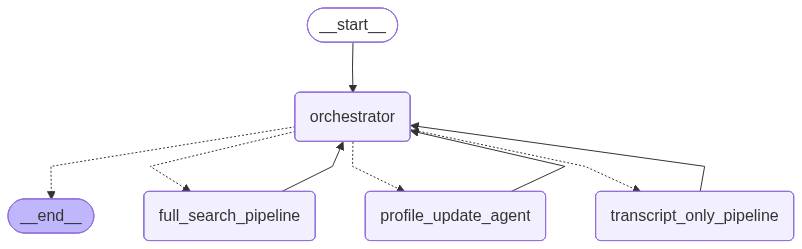

In [69]:
builder = StateGraph(State)
builder.add_node("orchestrator", orchestrator)
builder.add_node("full_search_pipeline", full_search_pipeline)
builder.add_node("transcript_only_pipeline", transcript_only_pipeline)
builder.add_node("profile_update_agent", profile_update_agent)

builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", route_intent)
builder.add_edge("full_search_pipeline", "orchestrator")
builder.add_edge("transcript_only_pipeline", "orchestrator")
builder.add_edge("profile_update_agent", "orchestrator")

# Store long-term
across_thread_memory = InMemoryStore()

# Store short-term
in_thread_memory = MemorySaver()

graph = builder.compile(checkpointer=in_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [83]:
# Invoke the graph
result = graph.stream(
    {"messages": [HumanMessage(content="Find me French cooking videos at B1")]},
    config={
        "configurable": {
            "thread_id": "test_thread_1",
            "user_id": "test_user"
        }
    }
)

for chunk in result:
    print(chunk)

BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. (insufficient tool messages following tool_calls message)", 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}

In [85]:
from langchain_core.messages import HumanMessage, SystemMessage

response = model.bind_tools([ExecuteIntent]).invoke([
    SystemMessage(content="You are a helpful assistant"),
    HumanMessage(content="Find me 5 French cooking videos at B1")
])
print(response)
print(response.tool_calls)

content='I can help you find French cooking videos at B1 level! However, I need to clarify one detail: when you say "B1", are you referring to the language proficiency level (like CEFR B1) or something else? \n\nIf you\'re looking for French language cooking videos suitable for B1 level learners, I can search for those. Could you confirm if that\'s what you mean?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 169, 'prompt_tokens': 653, 'total_tokens': 822, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 640}, 'prompt_cache_hit_tokens': 640, 'prompt_cache_miss_tokens': 13}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache', 'id': '99af8328-a92a-49f7-b3c2-0e1e24c5617c', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019ce544-3f1e-7e80-baa2-c8a8ee422cd8-0' tool_calls=[{'name': 'ExecuteIntent', 'args': {'intent